Train Regression (3 CLIP scores, and T -> predict best T) Model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import os
import random
# from torchsummary import summary

random_seed = 42
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)  # if use multi-GPU
np.random.seed(random_seed)
random.seed(random_seed)

os.environ["CUDA_VISIBLE_DEVICES"] = '3'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


Load Data

In [2]:
save_path = Path('/home/lbw/CLODE/traindata_csv/scores_csv_4prompts_400600')
# result_path = Path('/home/lbw/CLODE/traindata_csv/scores_csv_46_L/results.npy') # lol 모델로 뽑은 best T값과 PSNR
result_path = Path('/home/lbw/CLODE/traindata_csv/scores_csv_4prompts_400600/best_t_lowlightpth_v2.npy') # lol 모델로 뽑은 best T값에서 한번 더 뽑은 T값과 PSNR


# (485, 2): 485개 이미지에 대한, best T값과 그때의 PSNR
# lq_iqa_scores = np.load(save_path / 'clip_features.npy')
lq_iqa_scores = np.load(save_path / 'clip_features_L.npy')
results = np.load(result_path)

In [3]:
lq_iqa_scores = np.array(lq_iqa_scores).squeeze()
results = np.array(results)
print(lq_iqa_scores.shape, results.shape)

NUM_IMAGES = results.shape[0]
# NUM_T = 30



(485, 768) (485, 2)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import os
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image
import torchvision.transforms as transforms

# 데이터 로드
vision_cls = torch.tensor(np.load('/home/lbw/CLODE/traindata_csv/vision_cls_pca.npy'), dtype=torch.float32).to(device)  # (485, 512)

# 이미지 변환 정의
transform = transforms.Compose([
    # transforms.Resize((400, 600)),  # 원본 크기 유지
    transforms.ToTensor(),          # (3, 400, 600)으로 변환
    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 이미지 파일 경로
file_path = Path('/home/lbw/data/LOL/our485')
img_labels = [f for f in sorted(os.listdir(file_path / 'low')) if f.lower().endswith('.png')]

# 커스텀 데이터셋 정의
class CustomDataset(Dataset):
    def __init__(self, vision_cls, img_paths, labels, transform=None):
        self.vision_cls = vision_cls  # (485, 512)
        self.img_paths = img_paths    # 이미지 경로 리스트
        self.labels = labels          # 레이블 텐서
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # 이미지 로드
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image).to(device)  # (3, 400, 600)

        # vision_cls 데이터
        vision_data = self.vision_cls[idx]  # (512,)

        # 레이블
        label = self.labels[idx]  # 스칼라

        return (image, vision_data), label

# 이미지 경로 리스트 생성
img_paths = [file_path / 'low' / fname for fname in img_labels]

y = results[:, 0]

y = torch.tensor(y, dtype=torch.float32).to(device)


# Train/Test 분리
train_idx, test_idx = train_test_split(range(len(y)), test_size=0.2, random_state=42)

# 데이터셋 생성
train_dataset = CustomDataset(vision_cls[train_idx], [img_paths[i] for i in train_idx], y[train_idx], transform=transform)
test_dataset = CustomDataset(vision_cls[test_idx], [img_paths[i] for i in test_idx], y[test_idx], transform=transform)

# 데이터로더 생성
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# train_loader에서 한 배치 가져와서 크기 출력
for (images, vision_data), labels in train_loader:
    print(f"Image batch size: {images.shape}")         # 예상 출력: [B, 3, 400, 600]
    print(f"Vision_cls batch size: {vision_data.shape}")  # 예상 출력: [B, 512]
    print(f"Labels batch size: {labels.shape}")         # 예상 출력: [B]
    break  # 한 배치만 확인하고 종료

Image batch size: torch.Size([64, 3, 400, 600])
Vision_cls batch size: torch.Size([64, 512])
Labels batch size: torch.Size([64])


Load Model

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Regressor(nn.Module):
    def __init__(self, hidden_dim=32):
        super(Regressor, self).__init__()
        
        # Convolutional Layers for image (B, 3, 400, 600)
        self.conv1 = nn.Conv2d(3, hidden_dim // 4, kernel_size=3, stride=2, padding=1)    # (B, 8, 200, 300)
        self.conv2 = nn.Conv2d(hidden_dim // 4, hidden_dim // 2, kernel_size=3, stride=2, padding=1)   # (B, 16, 100, 150)
        self.pool = nn.AdaptiveAvgPool2d((5, 5))  # (B, 16, 5, 5)
        
        # 패치 투영 (입력 차원 16으로 수정)
        self.patch_proj = nn.Linear(16, hidden_dim)  # (16 -> 32)
        
        # vision_cls (B, 512)를 위한 선형 변환
        self.fc_vision = nn.Linear(512, hidden_dim)  # (B, 32)
        
        # Attention 대신 결합
        self.attn_fc = nn.Linear(hidden_dim + hidden_dim, hidden_dim)  # 이미지와 vision_cls를 결합 (64 -> 32)
        
        # 최종 출력 레이어
        self.fc_final = nn.Linear(hidden_dim, 1)  # (B, 1)
        
    def forward(self, image, vision_cls):
        # 이미지 처리 (B, 3, 400, 600)
        x = F.relu(self.conv1(image))    # (B, 8, 200, 300)
        x = F.relu(self.conv2(x))        # (B, 16, 100, 150)
        x = self.pool(x)                 # (B, 16, 5, 5)
        
        # (B, 16, 5, 5) -> (B, 16, 25) -> (B, 25, 16)
        x = x.view(x.size(0), 16, -1)    # (B, 16, 25)
        x = x.transpose(1, 2)            # (B, 25, 16)
        x = F.relu(self.patch_proj(x))   # (B, 25, 32)
        
        # 평균 풀링으로 단일 벡터로 축소
        x = x.mean(dim=1)                # (B, 32)
        
        # vision_cls 처리 (B, 512)
        v = F.relu(self.fc_vision(vision_cls))  # (B, 32)
        
        # Attention 대신 간단한 결합
        combined = torch.cat((x, v), dim=1)  # (B, 64)
        attn_output = F.relu(self.attn_fc(combined))  # (B, 32)
        
        # 최종 출력
        output = self.fc_final(attn_output)  # (B, 1)
        return output.squeeze(1)             # (B,)
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# 모델 테스트
if __name__ == "__main__":
    # 샘플 입력
    batch_size = 4
    image = torch.randn(batch_size, 3, 400, 600)
    vision_cls = torch.randn(batch_size, 512)
    
    # 모델 생성
    model = Regressor(hidden_dim=64)
    output = model(image, vision_cls)
    
    # 출력 크기 및 파라미터 수 출력
    print(f"Output shape: {output.shape}")  # 예상 출력: [4]
    print(f"Total parameters: {model.count_parameters():,}")  # 파라미터 수

# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class Regressor(nn.Module):
#     def __init__(self, hidden_dim=32):
#         super(Regressor, self).__init__()
        
#         # Convolutional Layers for image (B, 3, 400, 600)
#         self.conv1 = nn.Conv2d(3, 8, kernel_size=3, stride=2, padding=1)    # (B, 8, 200, 300)
#         self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1)   # (B, 16, 100, 150)
#         self.pool = nn.AdaptiveAvgPool2d((5, 5))  # (B, 16, 5, 5)
        
#         # Residual Connection을 위한 차원 맞춤 레이어
#         # conv1 출력(8채널)과 conv2 출력(16채널)을 맞추기 위해 1x1 Conv 사용
#         self.residual_conv = nn.Conv2d(8, 16, kernel_size=1, stride=2, padding=0)  # (B, 8, 200, 300) -> (B, 16, 100, 150)
        
#         # 패치 투영 (입력 차원 16으로 수정)
#         self.patch_proj = nn.Linear(16, 32)  # (16 -> 32)
        
#         # vision_cls (B, 512)를 위한 선형 변환
#         self.fc_vision = nn.Linear(512, 32)  # (B, 32)
        
#         # Attention 대신 결합
#         self.attn_fc = nn.Linear(32 + 32, 32)  # 이미지와 vision_cls를 결합 (64 -> 32)
        
#         # Residual Connection을 위한 차원 맞춤 레이어 (결합 레이어)
#         self.residual_fc = nn.Linear(64, 32)  # (B, 64) -> (B, 32) for residual
        
#         # 최종 출력 레이어
#         self.fc_final = nn.Linear(32, 1)  # (B, 1)
        
#     def forward(self, image, vision_cls):
#         # 이미지 처리 (B, 3, 400, 600)
#         x = F.relu(self.conv1(image))    # (B, 8, 200, 300)
        
#         # Residual Connection 준비
#         residual = self.residual_conv(x)  # (B, 8, 200, 300) -> (B, 16, 100, 150)
        
#         x = self.conv2(x)                # (B, 16, 100, 150)
        
#         # Residual Connection 추가: conv2 출력에 residual 더함
#         x = x + residual                # (B, 16, 100, 150)
#         x = F.relu(x)                   # 활성화 함수 적용
        
#         x = self.pool(x)                # (B, 16, 5, 5)
        
#         # (B, 16, 5, 5) -> (B, 16, 25) -> (B, 25, 16)
#         x = x.view(x.size(0), 16, -1)   # (B, 16, 25)
#         x = x.transpose(1, 2)           # (B, 25, 16)
#         x = F.relu(self.patch_proj(x))  # (B, 25, 32)
        
#         # 평균 풀링으로 단일 벡터로 축소
#         x = x.mean(dim=1)               # (B, 32)
        
#         # vision_cls 처리 (B, 512)
#         v = F.relu(self.fc_vision(vision_cls))  # (B, 32)
        
#         # Attention 대신 간단한 결합
#         combined = torch.cat((x, v), dim=1)  # (B, 64)
        
#         # Residual Connection 준비
#         residual_combined = self.residual_fc(combined)  # (B, 64) -> (B, 32)
        
#         attn_output = self.attn_fc(combined)  # (B, 32)
        
#         # Residual Connection 추가: attn_fc 출력에 residual 더함
#         attn_output = attn_output + residual_combined  # (B, 32)
#         attn_output = F.relu(attn_output)  # 활성화 함수 적용
        
#         # 최종 출력
#         output = self.fc_final(attn_output)  # (B, 1)
#         return output.squeeze(1)            # (B,)
    
#     def count_parameters(self):
#         return sum(p.numel() for p in self.parameters() if p.requires_grad)

# # 모델 테스트
# if __name__ == "__main__":
#     # 샘플 입력
#     batch_size = 4
#     image = torch.randn(batch_size, 3, 400, 600)
#     vision_cls = torch.randn(batch_size, 512)
    
#     # 모델 생성
#     model = Regressor()
#     output = model(image, vision_cls)
    
#     # 출력 크기 및 파라미터 수 출력
#     print(f"Output shape: {output.shape}")  # 예상 출력: [4]
#     print(f"Total parameters: {model.count_parameters():,}")  # 파라미터 수

Output shape: torch.Size([4])
Total parameters: 47,329


Train the Model

In [6]:
from tqdm import tqdm

num_epochs = 500
train_losses = []
test_losses = []
best_test_loss = 10
best_epoch = 0
learning_rate = 1e-4

hidden_dim = 64

regressor = Regressor(hidden_dim = hidden_dim).to(device)
criterion = torch.nn.HuberLoss(delta=1.0)

optimizer = optim.AdamW(regressor.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

# 학습 루프
for epoch in tqdm(range(num_epochs)):
    regressor.train()
    epoch_loss = 0.0
    
    for (images, vision_cls), targets in train_loader:
        images, vision_cls, targets = images.to(device), vision_cls.to(device), targets.to(device)
        
        # 모델 예측
        outputs = regressor(images, vision_cls)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    regressor.eval()
    test_loss = 0.0
    with torch.no_grad():
        for (images, vision_cls), targets in test_loader:
            images, vision_cls, targets = images.to(device), vision_cls.to(device), targets.to(device)

            # 모델 예측
            y_pred = regressor(images, vision_cls)
            test_loss += criterion(y_pred, targets).item()
    
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # 스케줄러 업데이트
    scheduler.step(avg_test_loss)
    
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        best_model = regressor.state_dict()
        best_epoch = epoch

# 모델 저장
model_path = Path("/home/lbw/CLODE/regression_pth/lol_soom_cls_img_ca_pca_64")
model_path.mkdir(exist_ok=True, parents=True)
torch.save(best_model, (model_path / f'att_regression_{best_epoch}.pth'))
print(f"Best epoch: {best_epoch}, Best test loss: {best_test_loss:.4f}")

/home/lbw/miniconda3/envs/CLODE_128_bw/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [29:25<00:00,  3.53s/it]

Best epoch: 158, Best test loss: 0.1059


Plot Train Result and Performance

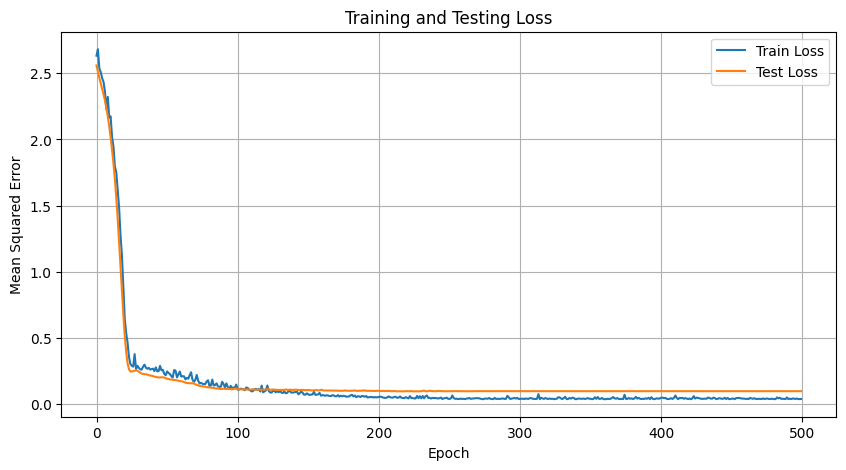

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training and Testing Loss')
plt.legend()
plt.grid(True)
plt.savefig(model_path / 'regression_training.png')
plt.show()

/tmp/ipykernel_3013306/1495197210.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  regressor.load_state_dict(torch.load((model_path / f'att_regression_{best_epoch}.pth'),

(388,) (388,)
MAE: 0.2197, RMSE: 0.2939, R²: 0.8876


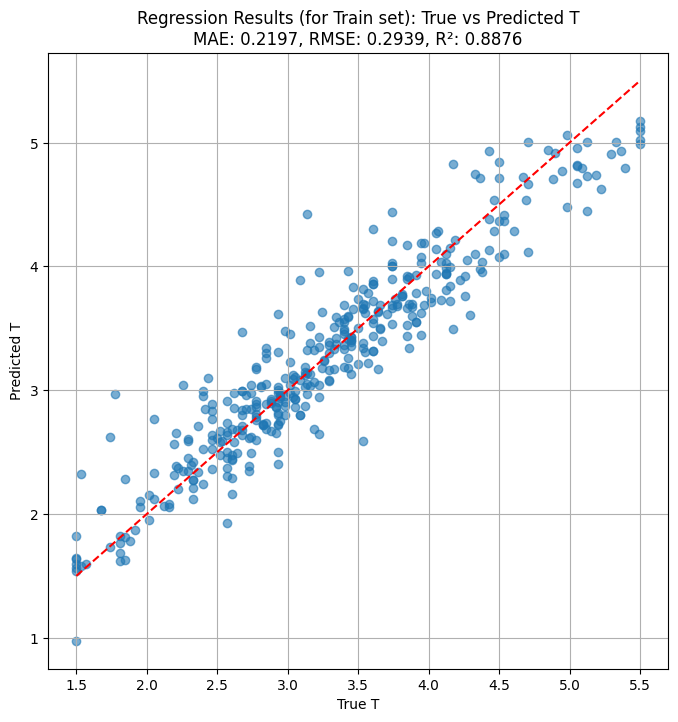

(97,) (97,)
MAE: 0.3363, RMSE: 0.4433, R²: 0.7185


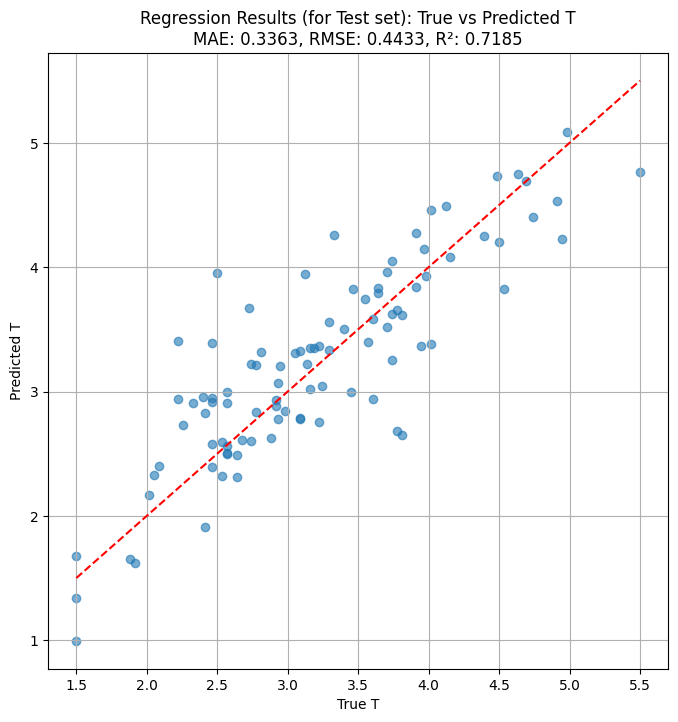

In [9]:
from sklearn.metrics import r2_score

regressor = Regressor(hidden_dim = hidden_dim).to(device)
regressor.load_state_dict(torch.load((model_path / f'att_regression_{best_epoch}.pth'), map_location=device))
regressor.eval()


def plot_regression_results(y_true, y_pred, title):
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    r2 = r2_score(y_true, y_pred)  # R² 스코어 계산
    
    print(f'MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}')

    plt.figure(figsize=(8, 8))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('True T')
    plt.ylabel('Predicted T')
    plt.title(f'{title}\nMAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}')
    plt.grid(True)
    plt.show()

# 예측 및 시각화
with torch.no_grad():
    # Train set 예측
    y_pred_train = []
    y_true_train = []
    for (images, vision_cls), targets in train_loader:
        images, vision_cls, targets = images.to(device), vision_cls.to(device), targets.to(device)
        outputs = regressor(images, vision_cls)
        y_pred_train.append(outputs.cpu().numpy())
        y_true_train.append(targets.cpu().numpy())
    
    y_pred_train = np.concatenate(y_pred_train, axis=0)  # (388,)
    y_true_train = np.concatenate(y_true_train, axis=0)  # (388,)

    print(y_pred_train.shape, y_true_train.shape)
    plot_regression_results(y_true_train, y_pred_train, 'Regression Results (for Train set): True vs Predicted T')

    # Test set 예측
    y_pred_test = []
    y_true_test = []
    for (images, vision_cls), targets in test_loader:
        images, vision_cls, targets = images.to(device), vision_cls.to(device), targets.to(device)
        outputs = regressor(images, vision_cls)
        y_pred_test.append(outputs.cpu().numpy())
        y_true_test.append(targets.cpu().numpy())
    
    y_pred_test = np.concatenate(y_pred_test, axis=0)  # (97,)
    y_true_test = np.concatenate(y_true_test, axis=0)  # (97,)
    
    print(y_pred_test.shape, y_true_test.shape)
    plot_regression_results(y_true_test, y_pred_test, 'Regression Results (for Test set): True vs Predicted T')

## Test할 때 T 없는 버전

In [10]:
import torch
from tqdm import tqdm
from network.conv_node import NODE
from misc import *
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from torchmetrics.multimodal import CLIPImageQualityAssessment
import time
from torchvision import transforms

# GPU 번호 지정
gpu_number = 3  # 원하는 GPU 번호로 변경 가능

# GPU 사용 제한
os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_number)

# 이제 GPU가 한 개만 보이므로 cuda:0으로 접근
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# NODE 모델 로드
model = NODE(device, (3, 400, 600), 32, augment_dim=0, time_dependent=True, adjoint=True)
model.eval()
model.to(device)
model.load_state_dict(torch.load(f'/home/lbw/CLODE/pth/lowlight.pth', weights_only=True), strict=False)

# 결과 저장을 위한 디렉토리 생성
results_dir = Path('/home/lbw/CLODE/result_img/lol_soom_cls_img_ca_pca_res')
results_dir.mkdir(parents=True, exist_ok=True)


# 하이퍼파라미터 설정
input_dim = 512
hidden_dim = 64

# Regressor 모델 초기화 및 로드
regressor = Regressor(hidden_dim=hidden_dim).to(device)
regressor.eval()
model_path_name = (model_path / f'att_regression_{best_epoch}.pth')
print(model_path_name, input_dim)
regressor.load_state_dict(torch.load(model_path_name, map_location=device))

# CLIP-IQA 로드 (eval15 데이터의 vision_cls 계산용)
clip_iqa = CLIPImageQualityAssessment(
    model_name_or_path="openai/clip-vit-base-patch16",
    prompts=('brightness', 'natural', 'colorfullness')
).to(device)

# Transform 정의
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                        std=[0.26862954, 0.26130258, 0.27577711])
])

# eval15 데이터 불러오기
eval_path = Path('/home/lbw/data/LOL/eval15')
eval_images = [f for f in sorted(os.listdir(eval_path / 'low')) if f.lower().endswith('.png')]

def load_eval_image(idx):
    img_name = eval_images[idx]
    lq_img = image_tensor(eval_path / 'low' / img_name)
    gt_img = image_tensor(eval_path / 'high' / img_name)
    
    # lq_img_224는 transform 적용
    lq_img_pil = Image.open(eval_path / 'low' / img_name).convert('RGB')
    lq_img_224 = transform(lq_img_pil).unsqueeze(0).to(device)  # (1, 3, 224, 224)
    
    # Vision CLS 계산
    with torch.no_grad():
        vision_feature = clip_iqa.model.vision_model(lq_img_224)[1]  # (1, 768)
        vision_cls = clip_iqa.model.visual_projection(vision_feature)  # (1, 768)
    
    return lq_img.to(device), gt_img.to(device), img_name, vision_cls.to(device)

def tensor_to_numpy(tensor):
    img = tensor.detach().cpu().numpy()
    if img.ndim == 3 and img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))
    img = np.clip(img, 0, 1)
    return img

pred_img = []
pred_Ts = []
pred_psnrs = []
pred_ssims = []

# 이미지별 NODE와 Regressor 결과 비교
for idx in tqdm(range(len(eval_images))):
    lq_img, gt_img, img_name, vision_cls = load_eval_image(idx)
    
    with torch.no_grad():        
        # Regressor로 T 예측
        pred_T = regressor(lq_img, vision_cls)
        pred_T = pred_T.item()
    
    with torch.no_grad():
        T_tensor = torch.tensor([0, pred_T]).float().to(device)
        pred = model(lq_img, T_tensor, inference=True)['output'][0]
        psnr = calculate_psnr(pred, gt_img).item()
        ssim_value = calculate_ssim(pred, gt_img)

    pred_img.append(pred)    
    pred_Ts.append(pred_T)
    pred_psnrs.append(psnr)
    pred_ssims.append(ssim_value)
    
    # 시각화
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.imshow(tensor_to_numpy(lq_img[0]))
    plt.title(f'Low Quality Image: {img_name}')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(tensor_to_numpy(gt_img[0]))
    plt.title('Ground Truth')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(tensor_to_numpy(pred))
    plt.title(f'Regressor Pred T={pred_T:.2f}, PSNR={psnr:.4f}dB, SSIM={ssim_value:.4f}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig(results_dir / f'{img_name.split(".")[0]}_compare.png')
    plt.close()

# 통계 정보 계산
print("모든 이미지 처리 완료!")
print(f"Predicted T PSNR 평균: {np.mean(pred_psnrs):.4f}dB")
print(f"Predicted T SSIM 평균: {np.mean(pred_ssims):.4f}")

/home/lbw/miniconda3/envs/CLODE_128_bw/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/lbw/CLODE/regression_pth/lol_soom_cls_img_ca_pca_res/att_regression_225.pth 512


/tmp/ipykernel_3013306/3526143905.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  regressor.load_state_dict(torch.load(model_path_name, map_location=device))
100%|█████

모든 이미지 처리 완료!
Predicted T PSNR 평균: 21.3331dB
Predicted T SSIM 평균: 0.7343
